In [1]:
import matplotlib.pyplot as plt
import xarray as xr
import rioxarray
import pandas as pd
import numpy as np
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from matplotlib.legend_handler import HandlerTuple
import os
from pathlib import Path

In [ ]:
projectDir = "/Users/rfk471/Dropbox/elevation-canada"

region_ids_model = ["01","02","03","04","05","06","12","15"]
region_ids_full = ["01","02","03","04","05","06","07","08","09","10","11","12","13","14","15"]

project_crs = "EPSG:3413"

In [3]:
full_cov = []

for r in range(len(region_ids_model)):
    region_id = region_ids_model[r]

    mask = rioxarray.open_rasterio(f"{projectDir}/data/interim/region-{region_id}/masks/mask_100m.tif",masked=True)

    s1 = xr.open_dataset(f"{projectDir}/data/interim/region-{region_id}/sentinel-1/S1_gathered_region-{region_id}.nc")['s1-backscatter'].rio.write_crs(project_crs).where(mask==1)
    s1count = s1.count(dim='time').squeeze().rio.write_transform(mask.rio.transform())
    s1count = s1count.where(s1count != 0)/44*100
    #s1count.rio.to_raster(f"{projectDir}/data/interim/region-{region_id}/s1_heatmap_region-{region_id}.tif")

    cs = xr.open_dataset(f"{projectDir}/data/interim/region-{region_id}/cryoswath_seasonal/cs_raw_gathered_region-{region_id}.nc")['cs-elevation'].rio.write_crs(project_crs).where(mask==1)
    cscount = cs.count(dim='time').squeeze().rio.write_transform(mask.rio.transform())
    cscount = cscount.where(cscount != 0)/44*100
    #cscount.rio.to_raster(f"{projectDir}/data/interim/region-{region_id}/cs_heatmap_region-{region_id}.tif")

    adem = xr.open_dataset(f"{projectDir}/data/interim/region-{region_id}/ArcticDEM/ArcticDEM_raw_gathered_region-{region_id}.nc")['adem-elevation'].rio.write_crs(project_crs).where(mask==1)
    ademcount = adem.count(dim='time').squeeze().rio.write_transform(mask.rio.transform())
    ademcount = ademcount.where(ademcount != 0)/44*100
    #ademcount.rio.to_raster(f"{projectDir}/data/interim/region-{region_id}/adem_heatmap_region-{region_id}.tif")
    
    full = mask.where(mask==1).count().values
    full_cov.append(full)

    if r == 0:
        df = pd.DataFrame({"time":pd.to_datetime(cs.time)})
    
    adem_cov, s1_cov, cs_cov = [], [], []
    for i in range(len(cs.time)):
        t = df.time.iloc[i]

        if t in adem.time.values:
            adem_cov.append(adem.sel(time=t).count().values/full*100)
        else:
            adem_cov.append(0)
        
        if t in s1.time.values:
            s1_cov.append(s1.sel(time=t).count().values/full*100)
        else:
            s1_cov.append(0)
        
        cs_cov.append(cs.sel(time=t).count().values/full*100)

    df[f"adem_cov_{region_id}"], df[f"cs_cov_{region_id}"], df[f"s1_cov_{region_id}"] = adem_cov, cs_cov, s1_cov



In [5]:
cov_cols = sorted(col for col in df.columns if col.startswith("adem_cov_"))
df["adem_cov"] = (df[cov_cols].mul(full_cov, axis=1).sum(axis=1)/np.sum(full_cov))
cov_cols = sorted(col for col in df.columns if col.startswith("cs_cov_"))
df["cs_cov"] = (df[cov_cols].mul(full_cov, axis=1).sum(axis=1)/np.sum(full_cov))
cov_cols = sorted(col for col in df.columns if col.startswith("s1_cov_"))
df["s1_cov"] = (df[cov_cols].mul(full_cov, axis=1).sum(axis=1)/np.sum(full_cov))

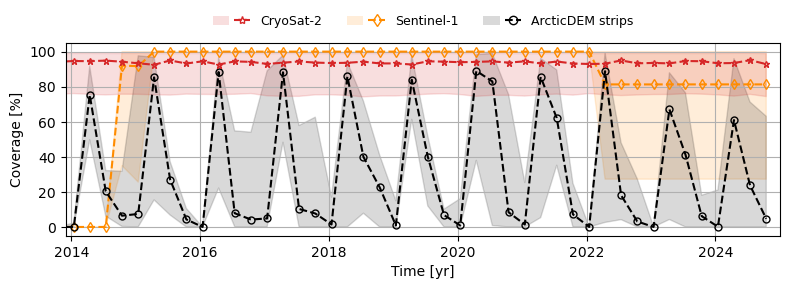

In [7]:
fig, ax = plt.subplots(figsize=(8,3))

# Compute min/max across regions (ax[0]-ax[5])
cs_stack = np.vstack([df[f"cs_cov_{r}"] for r in region_ids_model])
s1_stack = np.vstack([df[f"s1_cov_{r}"] for r in region_ids_model])
adem_stack = np.vstack([df[f"adem_cov_{r}"] for r in region_ids_model])

cs_min, cs_max = cs_stack.min(axis=0), cs_stack.max(axis=0)
s1_min, s1_max = s1_stack.min(axis=0), s1_stack.max(axis=0)
adem_min, adem_max = adem_stack.min(axis=0), adem_stack.max(axis=0)

# Plot shaded range

ax.fill_between(df.time, s1_min, s1_max, alpha=0.15, color='darkorange')
ax.fill_between(df.time, adem_min, adem_max, alpha=0.15, color='k')
ax.fill_between(df.time, cs_min, cs_max, alpha=0.15, color='tab:red')

# Plot all-region curves

ax.plot(df.time, df["s1_cov"], '--d', color='darkorange', markerfacecolor='none', markersize=5, label='Sentinel-1 range')
ax.plot(df.time, df["adem_cov"], '--o', color='k', markerfacecolor='none', markersize=5, label='ArcticDEM range')
ax.plot(df.time, df["cs_cov"], '--*', color='tab:red', markerfacecolor='none', markersize=5, label='CryoSat-2 range')

ax.set_ylabel("Coverage [%]")
ax.set_xlabel("Time [yr]")

#ax.legend(fontsize=8, loc="upper right")

# CryoSat-2
cs_patch = Patch(facecolor='tab:red', alpha=0.15, edgecolor='none')
cs_line  = Line2D([], [], linestyle='--', marker='*', color='tab:red',
                  markerfacecolor='none', markersize=6)

# Sentinel-1
s1_patch = Patch(facecolor='darkorange', alpha=0.15, edgecolor='none')
s1_line  = Line2D([], [], linestyle='--', marker='d', color='darkorange',
                  markerfacecolor='none', markersize=6)

# ArcticDEM
adem_patch = Patch(facecolor='k', alpha=0.15, edgecolor='none')
adem_line  = Line2D([], [], linestyle='--', marker='o', color='k',
                    markerfacecolor='none', markersize=6)

# --- legend using tuple handles ---
handles = [
    (cs_patch, cs_line),
    (s1_patch, s1_line),
    (adem_patch, adem_line)
]

labels = ['CryoSat-2', 'Sentinel-1', 'ArcticDEM strips']

legend = ax.legend(
    handles, labels,
    handler_map={tuple: HandlerTuple(ndivide=None)},
    loc='lower center',
    bbox_to_anchor=(0.5, 1.02),   # place above plot
    ncol=3,                       # all on one row
    columnspacing=2.0,
    handlelength=3,
    fontsize=9,
    frameon=False
)
ax.set_xlim(pd.to_datetime('2013-12-01'),pd.to_datetime('2025-01-01'))
plt.tight_layout()
plt.grid()

fig.savefig(f"{projectDir}/figures/temporal_coverage_vector.png",dpi=300)